Here, a simple MLP will be trained in a classification task using the MNIST dataset -- which contains images of hand-written digits. Importing the libraries.

In [ ]:
#| echo: true
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

Setting the device.

In [ ]:
#| echo: true
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Normalizing and creating the dataloaders.

In [ ]:
#| echo: true
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: torch.flatten(x))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.47MB/s]


Creating and instantiating the MLP. A model with one hidden layer containing 128 neurons and ReLU activations will be used.

In [ ]:
#| echo: true
class MLP(nn.Module):
    def __init__(
            self,
            input_size=784,
            hidden_size=128,
            output_size=10
        ):
        super(MLP, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.classifier(x)

    def fit(
            self,
            device,
            train_loader,
            optimizer,
            criterion,
            epochs
        ):
        self.train()
        self.train_loss = []

        for epoch in range(1, epochs + 1):
            epoch_loss = 0.0

            for data, target in train_loader:
                data, target = data.to(device), target.to(device)

                optimizer.zero_grad()
                output = self(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_loss = epoch_loss / len(train_loader)
            self.train_loss.append(avg_loss)
            print(f"Epoch [{epoch}/{epochs}] | Average Loss: {avg_loss:.6f}")

model = MLP().to(device)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of params: {params}")

Number of params: 118282


Making the training loop.

In [ ]:
#| echo: true
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

model.fit(device, train_loader, optimizer, criterion, epochs=10)

Epoch [1/10] | Average Loss: 0.825505
Epoch [2/10] | Average Loss: 0.316130
Epoch [3/10] | Average Loss: 0.261313
Epoch [4/10] | Average Loss: 0.223332
Epoch [5/10] | Average Loss: 0.193474
Epoch [6/10] | Average Loss: 0.170477
Epoch [7/10] | Average Loss: 0.152012
Epoch [8/10] | Average Loss: 0.136417
Epoch [9/10] | Average Loss: 0.123799
Epoch [10/10] | Average Loss: 0.112818


Plotting the training curve.

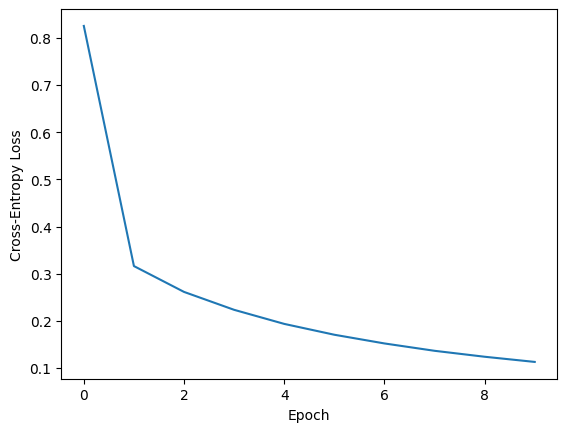

In [ ]:
#| echo: true
plt.plot(model.train_loss)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()

Calculating the metrics.

In [ ]:
#| echo: true
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        preds = output.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

print(classification_report(all_targets, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9660    0.9867    0.9763       980
           1     0.9756    0.9850    0.9803      1135
           2     0.9691    0.9738    0.9715      1032
           3     0.9542    0.9703    0.9622      1010
           4     0.9595    0.9654    0.9624       982
           5     0.9638    0.9552    0.9595       892
           6     0.9629    0.9749    0.9689       958
           7     0.9666    0.9582    0.9624      1028
           8     0.9755    0.9384    0.9566       974
           9     0.9617    0.9445    0.9530      1009

    accuracy                         0.9656     10000
   macro avg     0.9655    0.9652    0.9653     10000
weighted avg     0.9656    0.9656    0.9655     10000



Plotting the confusion matrix.

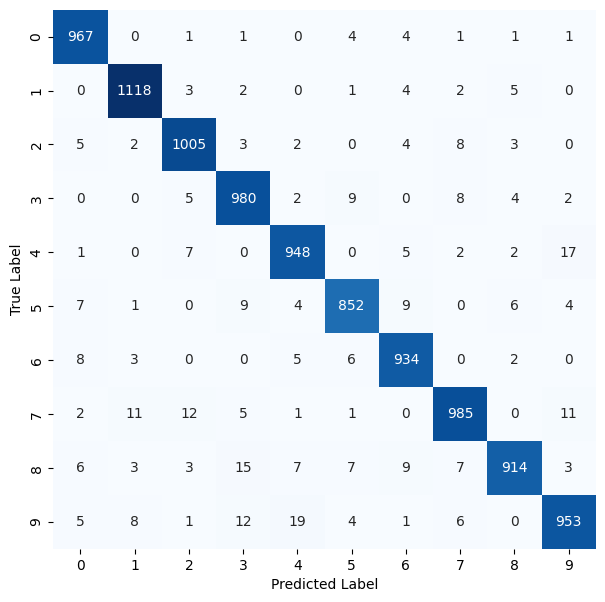

In [ ]:
#| echo: true
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(7, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()